# Experiment 4.0.4 — Hidden-state memory vs fully-spiking readout

This notebook is analysis-only. The 20 probes are produced by the Slurm array runner.

Question: for the frozen Exp4.0.1 RSNN H128 / tau=250 ms checkpoints, especially Multi-H `(31,1)`, does poor fully-spiking WholeCount accuracy reflect poor recurrent hidden memory or information loss after the hidden endpoint state?

The Linear probe sees only one 128-D post-reset hidden membrane vector at the causal valid endpoint. It does not see phase-wise Fixed250 vectors or output-neuron states.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'AGENTS.md').exists():
    repo_root = repo_root.parent
root = repo_root / 'notebooks' / 'artifacts' / 'experiment_4_0_4_hidden_state_probe' / 'rsnn_cap_variant_endpoint_state_probe_v1'
summary = pd.read_csv(root / 'summary.csv')
runs = pd.read_csv(root / 'runs.csv')
paired = pd.read_csv(root / 'paired_effects.csv')
summary

,variant,hidden_cap,output_cap,valid_count_balanced_accuracy_mean,valid_count_balanced_accuracy_std,valid_count_macro_f1_mean,valid_count_macro_f1_std,state_probe_balanced_accuracy_mean,state_probe_balanced_accuracy_std,state_probe_macro_f1_mean,state_probe_macro_f1_std,probe_minus_fully_spiking_ba_mean,probe_minus_fully_spiking_ba_std,probe_minus_fully_spiking_macro_f1_mean,probe_minus_fully_spiking_macro_f1_std
0,binary,1,1,0.354349,0.032936,0.334560,0.030613,0.413205,0.042817,0.407258,0.044740,0.058856,0.030847,0.072698,0.032341
1,multi_h,31,1,0.245826,0.058430,0.206272,0.081671,0.440073,0.021811,0.429430,0.019287,0.194247,0.039732,0.223158,0.064302
2,multi_ho,31,31,0.407640,0.025049,0.395307,0.023457,0.462232,0.056854,0.455014,0.057947,0.054592,0.055502,0.059707,0.065226
3,multi_o,1,31,0.327240,0.032732,0.308788,0.037193,0.438150,0.051485,0.437833,0.051238,0.110910,0.021681,0.129045,0.020724


## Primary diagnostic

Compare each variant's original fully-spiking valid WholeCount BA with the post-hoc endpoint hidden-state Linear-probe BA. A large positive `probe_minus_fully_spiking_ba` means class information is available in the recurrent hidden endpoint state but is not fully exposed by the existing hidden-to-output spiking/readout path.

In [2]:
test = runs[runs['split'] == 'test'].copy()
test['probe_minus_fully_spiking_ba'] = test['state_probe_balanced_accuracy'] - test['valid_count_balanced_accuracy']
display_cols = [
    'variant', 'hidden_cap', 'output_cap', 'seed',
    'valid_count_balanced_accuracy',
    'state_probe_balanced_accuracy',
    'probe_minus_fully_spiking_ba',
]
test[display_cols].sort_values(['variant', 'seed'])

,variant,hidden_cap,output_cap,seed,valid_count_balanced_accuracy,state_probe_balanced_accuracy,probe_minus_fully_spiking_ba
2,binary,1,1,11,0.362208,0.420972,0.058764
5,binary,1,1,23,0.372749,0.390732,0.017983
8,binary,1,1,37,0.310388,0.354307,0.043919
11,binary,1,1,53,0.393611,0.467187,0.073576
14,binary,1,1,71,0.332789,0.432826,0.100037
17,multi_h,31,1,11,0.327191,0.458154,0.130963
20,multi_h,31,1,23,0.244186,0.448529,0.204343
23,multi_h,31,1,37,0.176215,0.406342,0.230126
26,multi_h,31,1,53,0.208086,0.430618,0.222532
29,multi_h,31,1,71,0.273452,0.456723,0.183271


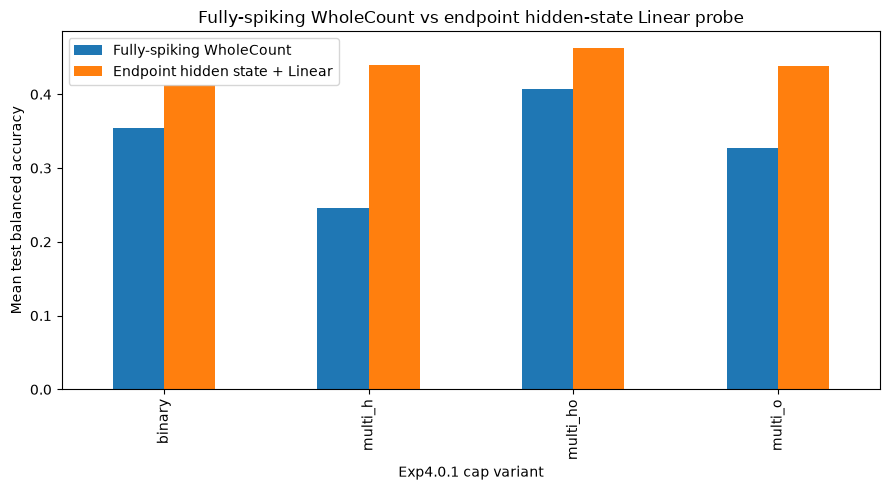

In [3]:
plot_data = test.groupby('variant')[['valid_count_balanced_accuracy', 'state_probe_balanced_accuracy']].mean()
ax = plot_data.plot(kind='bar', figsize=(9, 5))
ax.set_ylabel('Mean test balanced accuracy')
ax.set_xlabel('Exp4.0.1 cap variant')
ax.set_title('Fully-spiking WholeCount vs endpoint hidden-state Linear probe')
ax.legend(['Fully-spiking WholeCount', 'Endpoint hidden state + Linear'])
plt.tight_layout()
plt.show()

## Multi-H interpretation

Focus on `multi_h` `(hidden cap=31, output cap=1)`.

- Probe BA close to its poor fully-spiking BA: the recurrent hidden state itself is poor.
- Probe BA much higher than fully-spiking BA: useful memory exists before the binary output bottleneck.
- Probe BA near Multi-HO probe BA while fully-spiking Multi-H remains much worse: strong evidence that the output cap/readout path, rather than hidden memory, explains most of the Multi-H failure.

In [4]:
paired.sort_values(['variant', 'seed'])

,variant,hidden_cap,output_cap,seed,fully_spiking_ba,state_probe_ba,probe_minus_fully_spiking_ba,fully_spiking_delta_vs_binary,state_probe_delta_vs_binary
0,binary,1,1,11,0.362208,0.420972,0.058764,0.000000,0.000000
1,binary,1,1,23,0.372749,0.390732,0.017983,0.000000,0.000000
2,binary,1,1,37,0.310388,0.354307,0.043919,0.000000,0.000000
3,binary,1,1,53,0.393611,0.467187,0.073576,0.000000,0.000000
4,binary,1,1,71,0.332789,0.432826,0.100037,0.000000,0.000000
5,multi_h,31,1,11,0.327191,0.458154,0.130963,-0.035017,0.037182
6,multi_h,31,1,23,0.244186,0.448529,0.204343,-0.128562,0.057797
7,multi_h,31,1,37,0.176215,0.406342,0.230126,-0.134173,0.052034
8,multi_h,31,1,53,0.208086,0.430618,0.222532,-0.185525,-0.036569
9,multi_h,31,1,71,0.273452,0.456723,0.183271,-0.059336,0.023898
